In [0]:
# Подключение к Azure Data Lake Storage Gen2
storage_account_name = "nycanalyticsdl"
storage_account_key = "D5omSVXf++LjsoBmbRRPpgI2MpWVZOPE8o5ndNtag0HghD6BiFAdC58t63lTttlqhk6PtOtwdp6Z+ASt8OWPyQ=="

spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
    storage_account_key
)

print("Connected to Data Lake!")

Connected to Data Lake!


In [0]:
# Читаем все 12 файлов NYC Taxi из Bronze
df_taxi = spark.read.parquet(
    "abfss://bronze@nycanalyticsdl.dfs.core.windows.net/taxi/"
)

print(f"Строк: {df_taxi.count()}")
print(f"Колонки: {df_taxi.columns}")
df_taxi.show(5)

Строк: 41169720
Колонки: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------

In [0]:
from pyspark.sql import functions as F

df_silver = df_taxi \
    .filter(F.col("passenger_count") > 0) \
    .filter(F.col("trip_distance") > 0) \
    .filter(F.col("fare_amount") > 0) \
    .filter(F.col("total_amount") > 0) \
    .filter(F.col("tpep_pickup_datetime").isNotNull()) \
    .withColumn("pickup_date", F.to_date("tpep_pickup_datetime")) \
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime")) \
    .withColumn("trip_duration_min", 
        F.round((F.unix_timestamp("tpep_dropoff_datetime") - 
                 F.unix_timestamp("tpep_pickup_datetime")) / 60, 2)) \
    .filter(F.col("trip_duration_min") > 0) \
    .filter(F.col("trip_duration_min") < 300) \
    .select(
        "VendorID", "pickup_date", "pickup_hour",
        "tpep_pickup_datetime", "tpep_dropoff_datetime",
        "trip_duration_min", "passenger_count", "trip_distance",
        "PULocationID", "DOLocationID", "payment_type",
        "fare_amount", "tip_amount", "total_amount",
        "congestion_surcharge", "Airport_fee"
    )

print(f"После очистки: {df_silver.count()} строк")
print(f"Удалено: {41169720 - df_silver.count()} строк")

После очистки: 35605499 строк
Удалено: 5564221 строк


In [0]:
# Сохраняем очищенные данные в Silver
df_silver.write \
    .mode("overwrite") \
    .parquet("abfss://silver@nycanalyticsdl.dfs.core.windows.net/taxi/")

print("Silver taxi данные сохранены!")

Silver taxi данные сохранены!


In [0]:
# Читаем OpenAQ из Bronze
df_openaq = spark.read.option("multiline", "true") \
    .json("abfss://bronze@nycanalyticsdl.dfs.core.windows.net/air_quality/openaq_pm25_2024.json")

print(f"Строк: {df_openaq.count()}")
df_openaq.printSchema()

Строк: 1
root
 |-- meta: struct (nullable = true)
 |    |-- found: string (nullable = true)
 |    |-- limit: long (nullable = true)
 |    |-- name: string (nullable = true)
 |    |-- page: long (nullable = true)
 |    |-- website: string (nullable = true)
 |-- results: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- bounds: array (nullable = true)
 |    |    |    |-- element: double (containsNull = true)
 |    |    |-- coordinates: struct (nullable = true)
 |    |    |    |-- latitude: double (nullable = true)
 |    |    |    |-- longitude: double (nullable = true)
 |    |    |-- country: struct (nullable = true)
 |    |    |    |-- code: string (nullable = true)
 |    |    |    |-- id: long (nullable = true)
 |    |    |    |-- name: string (nullable = true)
 |    |    |-- datetimeFirst: struct (nullable = true)
 |    |    |    |-- local: string (nullable = true)
 |    |    |    |-- utc: string (nullable = true)
 |    |    |-- datetimeLast: struc

In [0]:
from pyspark.sql import functions as F

# Разворачиваем массив results
df_locations = df_openaq.select(F.explode("results").alias("location"))

# Смотрим на локации
df_locations.select(
    "location.id",
    "location.name",
    "location.locality",
    "location.coordinates.latitude",
    "location.coordinates.longitude",
    "location.sensors"
).show(10, truncate=False)

+---+--------------------+--------+---------+----------+-------------------------------------------------------------------------------------+
|id |name                |locality|latitude |longitude |sensors                                                                              |
+---+--------------------+--------+---------+----------+-------------------------------------------------------------------------------------+
|3  |NMA - Nima          |NULL    |5.58389  |-0.19968  |[{6, pm10 µg/m³, {PM10, 1, pm10, µg/m³}}, {5, pm25 µg/m³, {PM2.5, 2, pm25, µg/m³}}]  |
|4  |NMT - Nima          |NULL    |5.58165  |-0.19898  |[{7, pm10 µg/m³, {PM10, 1, pm10, µg/m³}}, {8, pm25 µg/m³, {PM2.5, 2, pm25, µg/m³}}]  |
|5  |JTA - Jamestown     |NULL    |5.5401139|-0.2103972|[{10, pm10 µg/m³, {PM10, 1, pm10, µg/m³}}, {9, pm25 µg/m³, {PM2.5, 2, pm25, µg/m³}}] |
|6  |ADT - Asylum Down   |NULL    |5.570722 |-0.2120555|[{11, pm10 µg/m³, {PM10, 1, pm10, µg/m³}}, {12, pm25 µg/m³, {PM2.5, 2, pm25, µg/m³}}]|

In [0]:
import requests
import json

api_key = "852616da405201deebd7c868c16eb521ff1ec6dc41b25b798e815363e484ee28"

# Ищем локации в Нью-Йорке
url = "https://api.openaq.org/v3/locations"
params = {
    "country_id": "US",
    "bbox": "-74.26,40.48,-73.70,40.92",  # Bounding box Нью-Йорка
    "limit": 100
}
headers = {"X-API-Key": api_key}

response = requests.get(url, params=params, headers=headers)
data = response.json()

print(f"Найдено локаций: {data['meta']['found']}")
for loc in data['results'][:5]:
    print(f"ID: {loc['id']}, Name: {loc['name']}, Locality: {loc.get('locality', 'N/A')}")

Найдено локаций: 62
ID: 384, Name: CCNY, Locality: New York-Northern New Jersey-Long Island
ID: 386, Name: Susan Wagner, Locality: None
ID: 625, Name: Manhattan/IS143, Locality: New York-Northern New Jersey-Long Island
ID: 626, Name: Bronx - IS52, Locality: New York-Northern New Jersey-Long Island
ID: 628, Name: Maspeth, Locality: New York-Northern New Jersey-Long Island


In [0]:
# Собираем ID сенсоров PM2.5 из всех локаций
sensor_ids = []

for loc in data['results']:
    for sensor in loc.get('sensors', []):
        if sensor['parameter']['name'] == 'pm25':
            sensor_ids.append({
                'sensor_id': sensor['id'],
                'location_id': loc['id'],
                'location_name': loc['name']
            })

print(f"Найдено PM2.5 сенсоров: {len(sensor_ids)}")
for s in sensor_ids[:10]:
    print(s)

Найдено PM2.5 сенсоров: 56
{'sensor_id': 673, 'location_id': 384, 'location_name': 'CCNY'}
{'sensor_id': 1097, 'location_id': 625, 'location_name': 'Manhattan/IS143'}
{'sensor_id': 1102, 'location_id': 626, 'location_name': 'Bronx - IS52'}
{'sensor_id': 1103, 'location_id': 628, 'location_name': 'Maspeth'}
{'sensor_id': 1152, 'location_id': 631, 'location_name': 'Queens'}
{'sensor_id': 1121, 'location_id': 642, 'location_name': 'PS 19'}
{'sensor_id': 1128, 'location_id': 648, 'location_name': 'Bklyn - PS 314'}
{'sensor_id': 1143, 'location_id': 662, 'location_name': 'Division Street'}
{'sensor_id': 1145, 'location_id': 664, 'location_name': 'Bklyn - PS274'}
{'sensor_id': 1146, 'location_id': 665, 'location_name': 'Bronx - IS74'}


In [0]:
import time

all_measurements = []

for sensor in sensor_ids:
    sid = sensor['sensor_id']
    url = f"https://api.openaq.org/v3/sensors/{sid}/measurements/daily"
    params = {
        "date_from": "2024-01-01",
        "date_to": "2024-12-31",
        "limit": 500
    }
    
    try:
        response = requests.get(url, params=params, headers=headers)
        data_s = response.json()
        
        for m in data_s.get('results', []):
            all_measurements.append({
                'sensor_id': sid,
                'location_id': sensor['location_id'],
                'location_name': sensor['location_name'],
                'date': m['period']['datetimeFrom']['utc'][:10],
                'pm25_avg': m['value'],
                'unit': m['parameter']['units']
            })
        
        time.sleep(0.3)  # пауза чтобы не превысить rate limit
        
    except Exception as e:
        print(f"Ошибка сенсор {sid}: {e}")

print(f"Загружено измерений: {len(all_measurements)}")

Загружено измерений: 17492


In [0]:
import pandas as pd

# Конвертируем в Spark DataFrame
df_aq = spark.createDataFrame(all_measurements)

# Сохраняем в Bronze
df_aq.write.mode("overwrite") \
    .json("abfss://bronze@nycanalyticsdl.dfs.core.windows.net/air_quality/openaq_nyc_2024.json")

# Silver трансформация
df_aq_silver = df_aq \
    .filter(F.col("pm25_avg").isNotNull()) \
    .filter(F.col("pm25_avg") > 0) \
    .filter(F.col("pm25_avg") < 500) \
    .withColumn("date", F.to_date("date")) \
    .withColumn("pm25_category", 
        F.when(F.col("pm25_avg") <= 12, "Good")
         .when(F.col("pm25_avg") <= 35, "Moderate")
         .when(F.col("pm25_avg") <= 55, "Unhealthy for Sensitive")
         .otherwise("Unhealthy"))

# Сохраняем в Silver
df_aq_silver.write.mode("overwrite") \
    .parquet("abfss://silver@nycanalyticsdl.dfs.core.windows.net/air_quality/")

print(f"Silver air quality сохранён: {df_aq_silver.count()} записей")

Silver air quality сохранён: 17432 записей


In [0]:
# Читаем World Bank GDP
df_gdp_raw = spark.read.option("multiline", "true") \
    .json("abfss://bronze@nycanalyticsdl.dfs.core.windows.net/economy/worldbank_gdp_usa.json")

df_gdp_raw.printSchema()
df_gdp_raw.show(3, truncate=False)

root
 |-- _corrupt_record: string (nullable = true)



---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5496414784518415>, line 6
      2 df_gdp_raw = spark.read.option("multiline", "true") \
      3     .json("abfss://bronze@nycanalyticsdl.dfs.core.windows.net/economy/worldbank_gdp_usa.json")
      5 df_gdp_raw.printSchema()
----> 6 df_gdp_raw.show(3, truncate=False)

File /databricks/spark/python/pyspark/sql/connect/dataframe.py:1161, in DataFrame.show(self, n, truncate, vertical)
   1160 def show(self, n: int = 20, truncate: Union[bool, int] = True, vertical: bool = False) -> None:
-> 1161     print(self._show_string(n, truncate, vertical))

File /databricks/spark/python/pyspark/sql/connect/dataframe.py:905, in DataFrame._show_string(self, n, truncate, vertical)
    888     except ValueError:
    889         raise PySparkTypeError(
    890             error_class="NOT_BOOL",
    891             message_parameters={
   (..

In [0]:
import requests

# Читаем GDP напрямую через API
url = "https://api.worldbank.org/v2/country/USA/indicator/NY.GDP.MKTP.CD"
params = {
    "format": "json",
    "per_page": 20,
    "mrv": 10
}

response = requests.get(url, params=params)
data = response.json()

# World Bank возвращает [metadata, data]
gdp_records = []
for item in data[1]:
    if item['value'] is not None:
        gdp_records.append({
            'country': item['country']['value'],
            'year': int(item['date']),
            'gdp_usd': float(item['value'])
        })

print(f"Загружено записей GDP: {len(gdp_records)}")
for r in gdp_records[:5]:
    print(r)

Загружено записей GDP: 10
{'country': 'United States', 'year': 2024, 'gdp_usd': 28750956130731.2}
{'country': 'United States', 'year': 2023, 'gdp_usd': 27292170793214.4}
{'country': 'United States', 'year': 2022, 'gdp_usd': 25604848907611.0}
{'country': 'United States', 'year': 2021, 'gdp_usd': 23315080560000.0}
{'country': 'United States', 'year': 2020, 'gdp_usd': 21060473613000.0}


In [0]:
# Читаем ECB FX из Bronze
df_fx = spark.read \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .csv("abfss://bronze@nycanalyticsdl.dfs.core.windows.net/economy/ecb_fx_usdeur.csv")

print(f"Строк: {df_fx.count()}")
df_fx.show(5)

Строк: 7066
+--------------------+----+--------+--------------+--------+----------+-----------+---------+----------+--------+-------------+-------+-----------+------+----------+-------------+--------+-----------+--------+-------+-----------+---------------+-----------+--------+--------+---------+-------------+----------+--------------------+--------------------+----+---------+
|                 KEY|FREQ|CURRENCY|CURRENCY_DENOM|EXR_TYPE|EXR_SUFFIX|TIME_PERIOD|OBS_VALUE|OBS_STATUS|OBS_CONF|OBS_PRE_BREAK|OBS_COM|TIME_FORMAT|BREAKS|COLLECTION|COMPILING_ORG|DISS_ORG|DOM_SER_IDS|PUBL_ECB|PUBL_MU|PUBL_PUBLIC|UNIT_INDEX_BASE|COMPILATION|COVERAGE|DECIMALS|NAT_TITLE|SOURCE_AGENCY|SOURCE_PUB|               TITLE|         TITLE_COMPL|UNIT|UNIT_MULT|
+--------------------+----+--------+--------------+--------+----------+-----------+---------+----------+--------+-------------+-------+-----------+------+----------+-------------+--------+-----------+--------+-------+-----------+---------------+-------

In [0]:
# Silver трансформация ECB FX
df_fx_silver = df_fx \
    .select(
        F.to_date("TIME_PERIOD", "yyyy-MM-dd").alias("date"),
        F.col("OBS_VALUE").cast("double").alias("usd_eur_rate")
    ) \
    .filter(F.col("date").isNotNull()) \
    .filter(F.col("usd_eur_rate").isNotNull()) \
    .filter(F.col("date") >= "2024-01-01")  # только 2024

# Silver трансформация GDP
df_gdp_silver = spark.createDataFrame(gdp_records) \
    .filter(F.col("year") >= 2020)

# Сохраняем оба в Silver
df_fx_silver.write.mode("overwrite") \
    .parquet("abfss://silver@nycanalyticsdl.dfs.core.windows.net/economy/fx/")

df_gdp_silver.write.mode("overwrite") \
    .parquet("abfss://silver@nycanalyticsdl.dfs.core.windows.net/economy/gdp/")

print(f"FX записей: {df_fx_silver.count()}")
print(f"GDP записей: {df_gdp_silver.count()}")

FX записей: 602
GDP записей: 5


In [0]:
# Gold — агрегация такси по дням
df_gold_taxi = df_silver \
    .groupBy("pickup_date", "PULocationID") \
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare_usd"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue_usd"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance_miles"),
        F.round(F.avg("trip_duration_min"), 2).alias("avg_duration_min"),
        F.round(F.avg("passenger_count"), 2).alias("avg_passengers")
    ) \
    .orderBy("pickup_date")

df_gold_taxi.write.mode("overwrite") \
    .parquet("abfss://gold@nycanalyticsdl.dfs.core.windows.net/taxi_daily/")

print(f"Gold taxi записей: {df_gold_taxi.count()}")
df_gold_taxi.show(5)

Gold taxi записей: 80620
+-----------+------------+----------+------------+-----------------+------------------+----------------+--------------+
|pickup_date|PULocationID|trip_count|avg_fare_usd|total_revenue_usd|avg_distance_miles|avg_duration_min|avg_passengers|
+-----------+------------+----------+------------+-----------------+------------------+----------------+--------------+
| 2002-12-31|         170|         2|        19.8|            56.22|              4.09|            5.17|           1.0|
| 2002-12-31|         237|         1|         7.9|             11.9|              0.67|             6.2|           1.0|
| 2002-12-31|          50|         1|        10.0|             18.0|               1.4|           25.23|           1.0|
| 2002-12-31|         138|         1|        37.3|            62.68|              7.77|            38.0|           1.0|
| 2008-12-31|         141|         1|        11.4|             19.9|              1.62|           11.33|           1.0|
+-----------+--

In [0]:
# Gold — агрегация такси по дням только за 2024
df_gold_taxi = df_silver \
    .filter(F.year("pickup_date") == 2024) \
    .groupBy("pickup_date", "PULocationID") \
    .agg(
        F.count("*").alias("trip_count"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare_usd"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue_usd"),
        F.round(F.avg("trip_distance"), 2).alias("avg_distance_miles"),
        F.round(F.avg("trip_duration_min"), 2).alias("avg_duration_min"),
        F.round(F.avg("passenger_count"), 2).alias("avg_passengers")
    ) \
    .orderBy("pickup_date")

df_gold_taxi.write.mode("overwrite") \
    .parquet("abfss://gold@nycanalyticsdl.dfs.core.windows.net/taxi_daily/")

print(f"Gold taxi записей: {df_gold_taxi.count()}")
df_gold_taxi.show(5)

Gold taxi записей: 80594
+-----------+------------+----------+------------+-----------------+------------------+----------------+--------------+
|pickup_date|PULocationID|trip_count|avg_fare_usd|total_revenue_usd|avg_distance_miles|avg_duration_min|avg_passengers|
+-----------+------------+----------+------------+-----------------+------------------+----------------+--------------+
| 2024-01-01|         123|         3|       12.73|             44.7|              1.84|           13.55|          1.67|
| 2024-01-01|         153|         1|         5.1|              7.6|              0.36|            3.25|           1.0|
| 2024-01-01|         238|      1090|       13.95|         22860.91|               2.4|           10.39|          1.46|
| 2024-01-01|         229|      1171|       14.04|         25216.49|              2.41|           10.75|           1.5|
| 2024-01-01|         164|      1811|       18.09|         47474.97|              3.08|           14.25|          1.68|
+-----------+--

In [0]:
# Gold — среднее PM2.5 по дням по всему Нью-Йорку
df_gold_aq = df_aq_silver \
    .groupBy("date") \
    .agg(
        F.round(F.avg("pm25_avg"), 2).alias("pm25_daily_avg"),
        F.round(F.max("pm25_avg"), 2).alias("pm25_daily_max"),
        F.round(F.min("pm25_avg"), 2).alias("pm25_daily_min"),
        F.count("sensor_id").alias("active_sensors")
    ) \
    .orderBy("date")

df_gold_aq.write.mode("overwrite") \
    .parquet("abfss://gold@nycanalyticsdl.dfs.core.windows.net/airquality_daily/")

print(f"Gold AQ записей: {df_gold_aq.count()}")
df_gold_aq.show(5)

Gold AQ записей: 2673
+----------+--------------+--------------+--------------+--------------+
|      date|pm25_daily_avg|pm25_daily_max|pm25_daily_min|active_sensors|
+----------+--------------+--------------+--------------+--------------+
|2016-03-06|          9.73|          19.5|           1.5|             3|
|2016-03-07|          30.3|          41.7|          20.7|             3|
|2016-03-10|         16.37|          22.9|          10.6|            12|
|2016-03-11|          5.36|          22.0|          1.34|            12|
|2016-03-12|          5.83|          20.8|           2.4|            13|
+----------+--------------+--------------+--------------+--------------+
only showing top 5 rows



In [0]:
# Gold — среднее PM2.5 только за 2024
df_gold_aq = df_aq_silver \
    .filter(F.year("date") == 2024) \
    .groupBy("date") \
    .agg(
        F.round(F.avg("pm25_avg"), 2).alias("pm25_daily_avg"),
        F.round(F.max("pm25_avg"), 2).alias("pm25_daily_max"),
        F.round(F.min("pm25_avg"), 2).alias("pm25_daily_min"),
        F.count("sensor_id").alias("active_sensors")
    ) \
    .orderBy("date")

df_gold_aq.write.mode("overwrite") \
    .parquet("abfss://gold@nycanalyticsdl.dfs.core.windows.net/airquality_daily/")

print(f"Gold AQ записей: {df_gold_aq.count()}")
df_gold_aq.show(5)

Gold AQ записей: 366
+----------+--------------+--------------+--------------+--------------+
|      date|pm25_daily_avg|pm25_daily_max|pm25_daily_min|active_sensors|
+----------+--------------+--------------+--------------+--------------+
|2024-01-01|          12.3|          20.4|          6.87|             6|
|2024-01-02|          6.36|          8.02|          4.25|             6|
|2024-01-03|          8.31|          13.4|          4.62|             6|
|2024-01-04|          9.16|          14.7|          5.63|             6|
|2024-01-05|          6.54|          8.81|          4.61|             6|
+----------+--------------+--------------+--------------+--------------+
only showing top 5 rows



In [0]:
# Gold — объединённая таблица mobility vs air quality
df_taxi_daily_total = df_silver \
    .filter(F.year("pickup_date") == 2024) \
    .groupBy("pickup_date") \
    .agg(
        F.count("*").alias("total_trips"),
        F.round(F.sum("total_amount"), 2).alias("total_revenue_usd"),
        F.round(F.avg("fare_amount"), 2).alias("avg_fare_usd")
    )

# Джойним с качеством воздуха
df_gold_combined = df_taxi_daily_total \
    .join(df_gold_aq, df_taxi_daily_total.pickup_date == df_gold_aq.date, "left") \
    .join(df_fx_silver, df_taxi_daily_total.pickup_date == df_fx_silver.date, "left") \
    .withColumn("total_revenue_eur", 
        F.round(F.col("total_revenue_usd") / F.col("usd_eur_rate"), 2)) \
    .select(
        "pickup_date", "total_trips", "total_revenue_usd",
        "total_revenue_eur", "avg_fare_usd", "usd_eur_rate",
        "pm25_daily_avg", "pm25_daily_max", "active_sensors"
    ) \
    .orderBy("pickup_date")

df_gold_combined.write.mode("overwrite") \
    .parquet("abfss://gold@nycanalyticsdl.dfs.core.windows.net/mobility_vs_airquality/")

print(f"Gold combined записей: {df_gold_combined.count()}")
df_gold_combined.show(5)

Gold combined записей: 366
+-----------+-----------+-----------------+-----------------+------------+------------+--------------+--------------+--------------+
|pickup_date|total_trips|total_revenue_usd|total_revenue_eur|avg_fare_usd|usd_eur_rate|pm25_daily_avg|pm25_daily_max|active_sensors|
+-----------+-----------+-----------------+-----------------+------------+------------+--------------+--------------+--------------+
| 2024-01-01|      67322|       2101521.04|             NULL|       21.98|        NULL|          12.3|          20.4|             6|
| 2024-01-02|      70428|       2180467.31|       1990203.82|       21.37|      1.0956|          6.36|          8.02|             6|
| 2024-01-03|      77390|        2265318.8|       2074657.75|       20.05|      1.0919|          8.31|          13.4|             6|
| 2024-01-04|      96717|       2685902.23|       2452206.91|       18.71|      1.0953|          9.16|          14.7|             6|
| 2024-01-05|      96310|        2599603.9

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# Конвертируем в Pandas для визуализации
df_viz = df_gold_combined.toPandas()
df_viz['pickup_date'] = pd.to_datetime(df_viz['pickup_date'])
df_viz = df_viz.sort_values('pickup_date')

print(f"Данных для визуализации: {len(df_viz)} дней")

Данных для визуализации: 366 дней


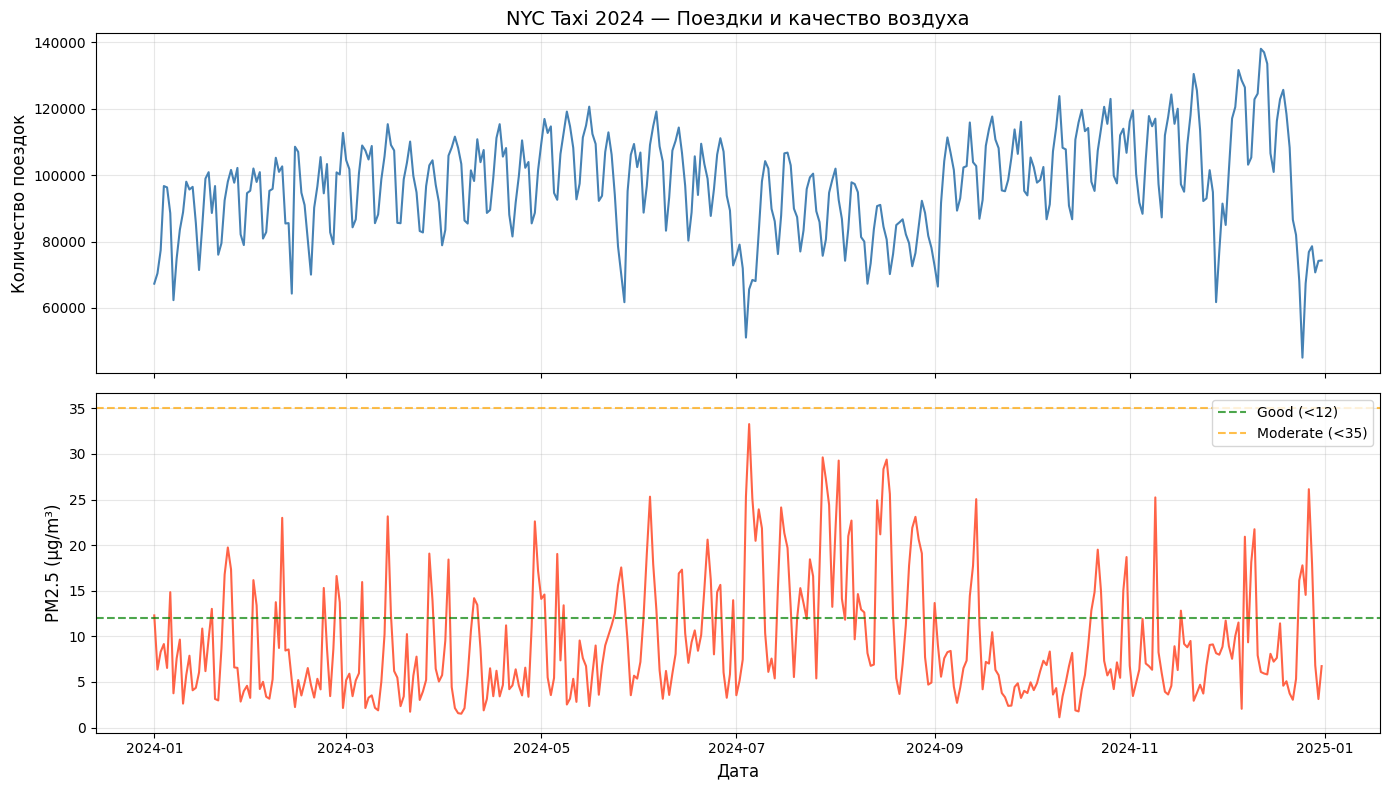

In [0]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# График 1 — количество поездок
ax1.plot(df_viz['pickup_date'], df_viz['total_trips'], 
         color='steelblue', linewidth=1.5)
ax1.set_ylabel('Количество поездок', fontsize=12)
ax1.set_title('NYC Taxi 2024 — Поездки и качество воздуха', fontsize=14)
ax1.grid(True, alpha=0.3)

# График 2 — PM2.5
ax2.plot(df_viz['pickup_date'], df_viz['pm25_daily_avg'], 
         color='tomato', linewidth=1.5)
ax2.axhline(y=12, color='green', linestyle='--', alpha=0.7, label='Good (<12)')
ax2.axhline(y=35, color='orange', linestyle='--', alpha=0.7, label='Moderate (<35)')
ax2.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax2.set_xlabel('Дата', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

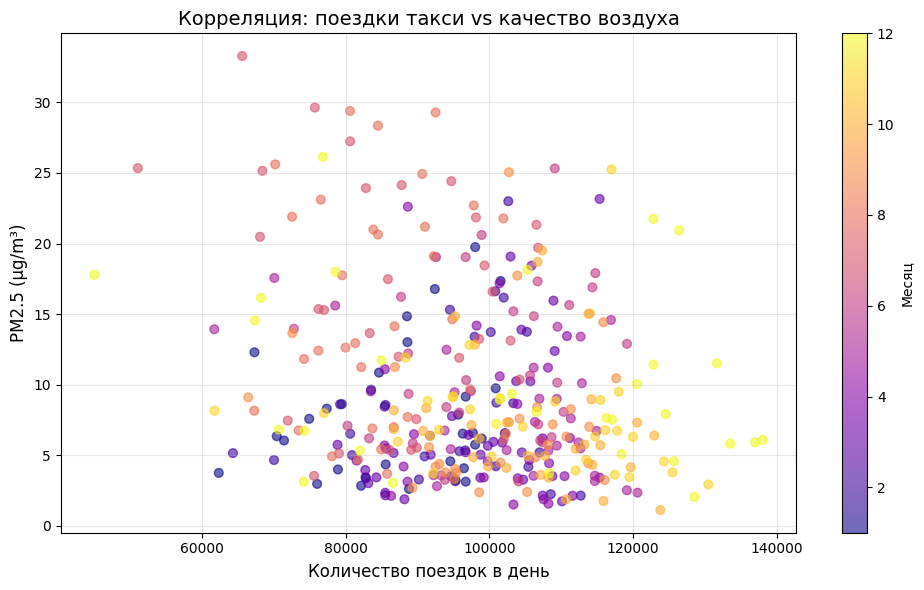

In [0]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_viz['total_trips'], 
    df_viz['pm25_daily_avg'],
    c=df_viz['pickup_date'].dt.month,
    cmap='plasma',
    alpha=0.6,
    s=40
)

plt.colorbar(scatter, label='Месяц')
ax.set_xlabel('Количество поездок в день', fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_title('Корреляция: поездки такси vs качество воздуха', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [0]:
import numpy as np

# Убираем NULL
df_corr = df_viz.dropna(subset=['total_trips', 'pm25_daily_avg'])

correlation = df_corr['total_trips'].corr(df_corr['pm25_daily_avg'])
print(f"Коэффициент корреляции Пирсона: {correlation:.3f}")

if abs(correlation) < 0.3:
    print("Слабая корреляция — такси мало влияет на PM2.5")
elif abs(correlation) < 0.7:
    print("Умеренная корреляция")
else:
    print("Сильная корреляция")

Коэффициент корреляции Пирсона: -0.197
Слабая корреляция — такси мало влияет на PM2.5


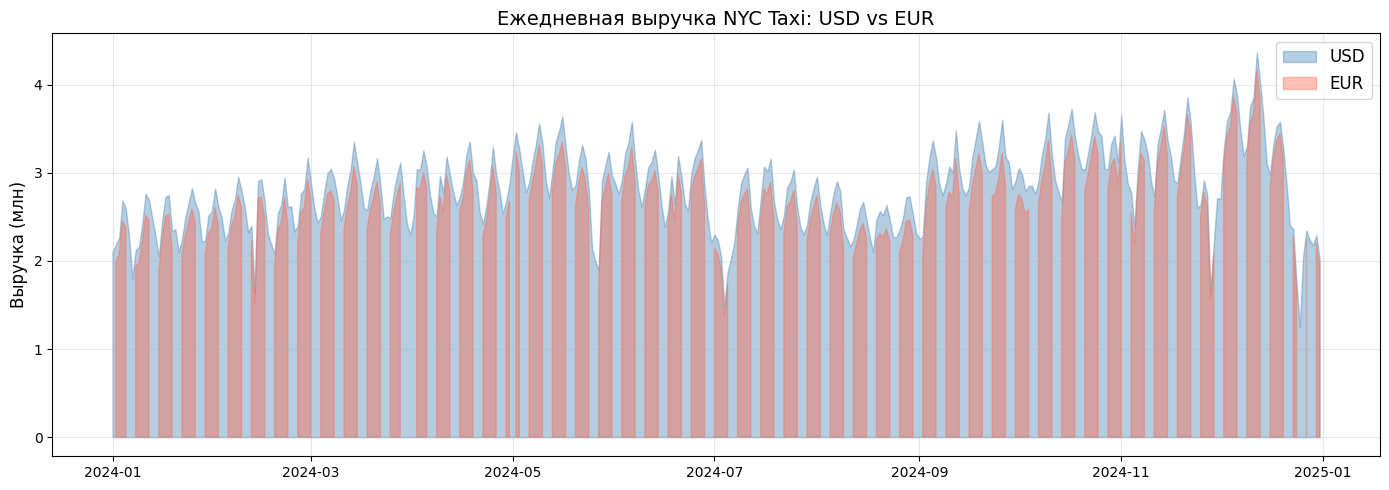

In [0]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_viz['pickup_date'], 
                df_viz['total_revenue_usd'] / 1e6,
                alpha=0.4, color='steelblue', label='USD')
ax.fill_between(df_viz['pickup_date'], 
                df_viz['total_revenue_eur'] / 1e6,
                alpha=0.4, color='tomato', label='EUR')

ax.set_ylabel('Выручка (млн)', fontsize=12)
ax.set_title('Ежедневная выручка NYC Taxi: USD vs EUR', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()